## Objetivo:

Implementar y contrastar dos modelos de clasificación —uno explicativo y otro predictivo— bajo criterios de rigor técnico y buenas prácticas de Data Mining y Modelización Predictiva.

### Sub-objetivos:
- Diferenciar y contrastar el enfoque de un modelo explicativo frente a uno predictivo en problemas de clasificación.
- Identificar y extraer los patrones clave de las features que determinan el comportamiento de la variable target.
- Optimizar el rendimiento predictivo mediante transformaciones de las features.

# Parte 0: Librerías

In [ ]:
# Importación de librerías

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import *
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

seed = 99

# Parte 0: Dataset

Los dos trabajos solitados se harán con el siguiente dataset de "Cancelación de reservas de hotel". Cada registro supone una reserva que ha sido cancelada o disfrutada por parte de clientes. A continuación, se da más detalle sobre las columnas:

**target**:
- *reserva_cancelada*: Indica si la reserva fue cancelada (1) o no cancelada (0).

**features**:
- *dias_antelacion*: Número de días que transcurren entre la fecha en la que el cliente hace la reserva y la fecha de su llegada al hotel.
- *fecha_llegada*: Fecha de comienzo de la reserva.
- *noches_estancia*: Noches totales de la reserva.
- *estado_reserva*: Estado final de la reserva. Valores: Canceled (el cliente canceló), Check-Out (el cliente disfrutó la reserva), No-Show (el cliente nunca apareció ni avisó).
- *fecha_estado_reserva*: Fecha de registro de la variable estado_reserva.
- *adultos*: Número de adultos incluidos en la reserva.
- *ninos*: Número de niños.
- *bebes*: Número de bebés.
- *regimen_alimenticio*: Régimen alimenticio contratado (BB: Solo desayuno, HB: Media pensión, FB: Pensión completa, SC/Undefined: Sin comidas).
- *tipo_habitacion_reservada*: Tipo de habitación que el cliente solicitó originalmente (codificado por letras: A, B, C...).
- *tipo_habitacion_asignada*: Tipo de habitación que el hotel le asignó finalmente en el momento del check-in.
- *plazas_parking_requeridas*: Número de plazas de parking que solicita el cliente.
- *peticiones_especiales_totales*: Número de peticiones especiales realizadas (ej. cuna, cama extra, piso alto).
- *pais_origen*: País de origen del cliente (en formato de código internacional de tres letras, ej. PRT, ESP, FRA).
- *segmento_mercado*: Segmento de mercado al que pertenece la reserva (ej. Directo, Grupos, Agencias de viaje corporativas, etc.).
- *canal_distribucion*: Canal por el que llegó la reserva al hotel (ej. TA/TO: Agencias/Operadores, Directo, GDS, etc.).
- *cliente_repetido*: Variable binaria (0 o 1). Indica si el cliente ya se ha alojado en este hotel en el pasado.
- *cancelaciones_previas*: Número de reservas que este cliente ha cancelado en el pasado antes de la reserva actual.
- *reservas_previas_no_canceladas*: Número de reservas anteriores que el cliente realizó y sí completó con éxito (no canceló).
- *tipo_deposito*: Indica si el cliente realizó un depósito para asegurar la reserva (No Deposit, Non Refundable [no reembolsable], Refundable [reembolsable]).
- *cambios_reserva*: Número de modificaciones o cambios hechos a la reserva desde que se creó hasta el día de la llegada.
- *dias_lista_espera*: Número de días que la reserva estuvo retenida en lista de espera antes de ser confirmada.
- *tipo_cliente*: Tipo de cliente/reserva (Transient: Particular suelto, Group: Grupo, Contract: Tarifa corporativa recurrente, Transient-Party: Particular ligado a grupo).
- *precio_medio_diario*: Precio medio diario (Average Daily Rate) que paga el cliente por noche de habitación.

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/eduardofc/data/refs/heads/main/reservas_hotel.csv")
df

,reserva_cancelada,dias_antelacion,adultos,ninos,bebes,regimen_alimenticio,pais_origen,segmento_mercado,canal_distribucion,cliente_repetido,cancelaciones_previas,reservas_previas_no_canceladas,tipo_habitacion_reservada,tipo_habitacion_asignada,cambios_reserva,tipo_deposito,dias_lista_espera,tipo_cliente,precio_medio_diario,plazas_parking_requeridas,peticiones_especiales_totales,estado_reserva,fecha_estado_reserva,fecha_llegada,noches_estancia
0,0,342,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01,2015-07-06,0
1,0,737,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01,2015-07-06,0
2,0,7,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02,2015-07-06,1
3,0,13,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02,2015-07-06,1
4,0,14,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.00,0,1,Check-Out,2015-07-03,2015-07-06,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,0,23,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,96.14,0,0,Check-Out,2017-09-06,2017-08-28,7
119386,0,102,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,0,Transient,225.43,0,2,Check-Out,2017-09-07,2017-08-28,7
119387,0,34,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,0,Transient,157.71,0,4,Check-Out,2017-09-07,2017-08-28,7
119388,0,109,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,104.40,0,0,Check-Out,2017-09-07,2017-08-28,7


In [ ]:
df.shape

(119390, 25)

In [ ]:
# Mantendremos la variable df para comparar cuando sea necesario.

df1 = df.copy()

In [ ]:
df1.columns

Index(['reserva_cancelada', 'dias_antelacion', 'adultos', 'ninos', 'bebes',
       'regimen_alimenticio', 'pais_origen', 'segmento_mercado',
       'canal_distribucion', 'cliente_repetido', 'cancelaciones_previas',
       'reservas_previas_no_canceladas', 'tipo_habitacion_reservada',
       'tipo_habitacion_asignada', 'cambios_reserva', 'tipo_deposito',
       'dias_lista_espera', 'tipo_cliente', 'precio_medio_diario',
       'plazas_parking_requeridas', 'peticiones_especiales_totales',
       'estado_reserva', 'fecha_estado_reserva', 'fecha_llegada',
       'noches_estancia'],
      dtype='object')

In [ ]:
df1.dtypes

reserva_cancelada                   int64
dias_antelacion                     int64
adultos                             int64
ninos                             float64
bebes                               int64
regimen_alimenticio                object
pais_origen                        object
segmento_mercado                   object
canal_distribucion                 object
cliente_repetido                    int64
cancelaciones_previas               int64
reservas_previas_no_canceladas      int64
tipo_habitacion_reservada          object
tipo_habitacion_asignada           object
cambios_reserva                     int64
tipo_deposito                      object
dias_lista_espera                   int64
tipo_cliente                       object
precio_medio_diario               float64
plazas_parking_requeridas           int64
peticiones_especiales_totales       int64
estado_reserva                     object
fecha_estado_reserva               object
fecha_llegada                     

# Parte 1: Tratamiento previo del dataset (EDA + Feature Engineering)

## Variables de fecha
Se identifican las variables de fecha y crear nuevas features que puedan ser de interés para encontrar "patrones" de cancelación.

In [ ]:
# No he generado variables a partir de "fecha_estado_reserva" para evitar data leakage, ya que esta fecha solo se conoce una vez que la reserva ha finalizado (cancelación, check-out o no-show). He trabajado, en cambio, con "fecha_llegada".

df1['fecha_llegada'] = pd.to_datetime(df1['fecha_llegada'])

df1['mes_llegada'] = df1['fecha_llegada'].dt.month

meses = {
    1: "01.Enero",
    2: "02.Febrero",
    3: "03.Marzo",
    4: "04.Abril",
    5: "05.Mayo",
    6: "06.Junio",
    7: "07.Julio",
    8: "08.Agosto",
    9: "09.Septiembre",
    10: "10.Octubre",
    11: "11.Noviembre",
    12: "12.Diciembre"}

df1["mes_llegada"] = df1["mes_llegada"].map(meses)

X = df1[['mes_llegada']]
ohe_mes = OneHotEncoder(drop='first')
X_mes = ohe_mes.fit_transform(X)

ohe_mes.categories_
X_mes.toarray()
ohe_mes.get_feature_names_out()

df_mes = pd.DataFrame(X_mes.toarray(), columns=ohe_mes.get_feature_names_out(), index=df1.index)

df1 = df1.merge(df_mes, left_index=True, right_index=True)

# Eliminación de las columnas de fecha
df1.drop(columns=['fecha_llegada','mes_llegada'], inplace=True)

df1

,reserva_cancelada,dias_antelacion,adultos,ninos,bebes,regimen_alimenticio,pais_origen,segmento_mercado,canal_distribucion,cliente_repetido,cancelaciones_previas,reservas_previas_no_canceladas,tipo_habitacion_reservada,tipo_habitacion_asignada,cambios_reserva,tipo_deposito,dias_lista_espera,tipo_cliente,precio_medio_diario,plazas_parking_requeridas,peticiones_especiales_totales,estado_reserva,fecha_estado_reserva,noches_estancia,mes_llegada_02.Febrero,mes_llegada_03.Marzo,mes_llegada_04.Abril,mes_llegada_05.Mayo,mes_llegada_06.Junio,mes_llegada_07.Julio,mes_llegada_08.Agosto,mes_llegada_09.Septiembre,mes_llegada_10.Octubre,mes_llegada_11.Noviembre,mes_llegada_12.Diciembre
0,0,342,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0,737,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0,7,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0,13,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0,14,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.00,0,1,Check-Out,2015-07-03,2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,0,23,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,96.14,0,0,Check-Out,2017-09-06,7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
119386,0,102,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,0,Transient,225.43,0,2,Check-Out,2017-09-07,7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
119387,0,34,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,0,Transient,157.71,0,4,Check-Out,2017-09-07,7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
119388,0,109,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,104.40,0,0,Check-Out,2017-09-07,7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


# Explicación de las nuevas columnas creadas

He extraído el año de la fecha de llegada y he creado variables dummy de los meses de llegada y la estación del año. Inicialmente extraje información de la variable "fecha_llegada" para el día, mes y año. Traté de crear nuevas variables relacionadas con los días (por ejemplo, el día de la semana o una variable dummy que reflejara si la reserva era en fin de semana, o no), pero todos los días de todos los registros eran lunes. Eso eliminaba mucha de la información de interés, así que opté por no extraer el día de la variable de origen. Me centré, entonces, en el mes. Primero extraje los meses en una variable donde se les asignó su valor numérico (julio->7; ["mes_llegada"]), pero sabía que esa codificación tendría algunos inconvenientes en el modelo de regresión logística (por ejemplo, algunos meses podrían tener más peso en el modelo por el mero hecho de tener asignado un valor más alto, como es el caso de noviembre o diciembre). Es por ello que convertí los meses en variables dummy con onehotencoder. Eso dio lugar a 12 variables, una por cada mes del año, con dos valores: 0 (no se llegó en ese mes) y 1 (se llegó en ese mes). Finalmente borré la variable intermedia ["mes_llegada"] y la variable original ["fecha_llegada"].

## Data split

In [ ]:
df1 = df1.drop(columns=["estado_reserva", "fecha_estado_reserva"])

target = "reserva_cancelada"

x = df1.drop(columns=target)
y = df1[target]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=seed)

## Imputación de nulos

Se exploran las variables con valores nulos en el dataset y se imputan.

In [ ]:
# Código del estudiante

df1.isnull().sum().sort_values(ascending=False)

pais_origen                       488
ninos                               4
reserva_cancelada                   0
mes_llegada_05.Mayo                 0
peticiones_especiales_totales       0
noches_estancia                     0
mes_llegada_02.Febrero              0
mes_llegada_03.Marzo                0
mes_llegada_04.Abril                0
mes_llegada_07.Julio                0
mes_llegada_06.Junio                0
precio_medio_diario                 0
mes_llegada_08.Agosto               0
mes_llegada_09.Septiembre           0
mes_llegada_10.Octubre              0
mes_llegada_11.Noviembre            0
plazas_parking_requeridas           0
dias_lista_espera                   0
tipo_cliente                        0
dias_antelacion                     0
tipo_deposito                       0
cambios_reserva                     0
tipo_habitacion_asignada            0
tipo_habitacion_reservada           0
reservas_previas_no_canceladas      0
cancelaciones_previas               0
cliente_repe

In [ ]:
# Código del estudiante

a = x_train[['pais_origen']]

si1 = SimpleImputer(strategy="most_frequent")
si1.fit(a)
a_new = si1.transform(a)
x_train[['pais_origen']] = a_new
x_test[['pais_origen']] = si1.transform(x_test[['pais_origen']])

b = x_train[['ninos']]

si2 = SimpleImputer(strategy="median")
si2.fit(b)
b_new = si2.transform(b)
x_train[['ninos']] = b_new
x_test[['ninos']] = si2.transform(x_test[['ninos']])

# Explicación de las imputaciones realizadas
Primero me he encargado de detectar los nulos/missings en el dataset con "isnull". He detectado sólo dos, que pertenecen al conjunto de posibles variables predictoras: "pais_origen" y "ninos". He optado por imputar la primera con la moda (el valor más frecuente) y el segundo con la mediana (más robusta que la media cuando se repiten muchos valores, como es el caso del 0 en esta variable). He usado el single imputer con el conjunto x_train y he aplicado el imputador resultante a los conjuntos de train y test (no he usado un imputador propio con test porque podría llegar a mezclarse la información de test con train).

## Exploración de features y creación de nuevas features

Se exploran con plots todas las features

In [ ]:
# Código del estudiante (opcional)

cat_cols = ["regimen_alimenticio","pais_origen","segmento_mercado","canal_distribucion","cliente_repetido","tipo_habitacion_reservada",
            "tipo_habitacion_asignada","tipo_deposito","tipo_cliente","mes_llegada_02.Febrero","mes_llegada_03.Marzo",
            "mes_llegada_04.Abril","mes_llegada_05.Mayo","mes_llegada_06.Junio","mes_llegada_07.Julio","mes_llegada_08.Agosto",
            "mes_llegada_09.Septiembre","mes_llegada_10.Octubre","mes_llegada_11.Noviembre","mes_llegada_12.Diciembre"]

num_cols = ["dias_antelacion","adultos","ninos","bebes","cancelaciones_previas","reservas_previas_no_canceladas","cambios_reserva",
            "dias_lista_espera","precio_medio_diario","plazas_parking_requeridas","peticiones_especiales_totales","noches_estancia"]

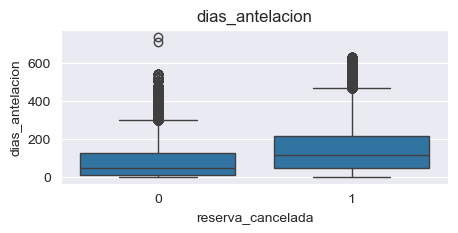

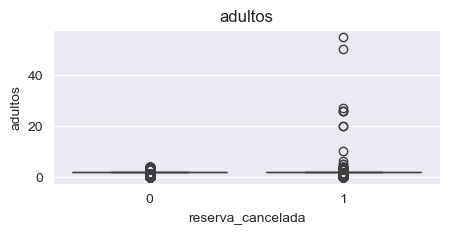

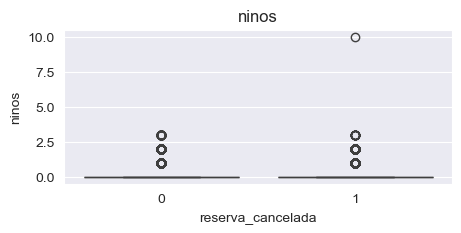

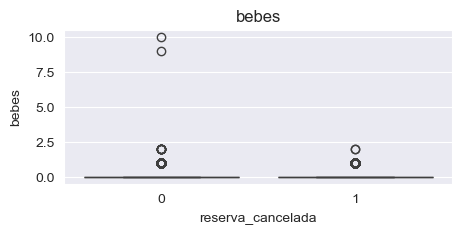

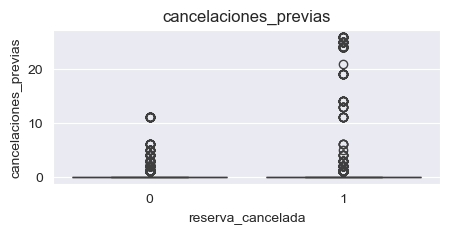

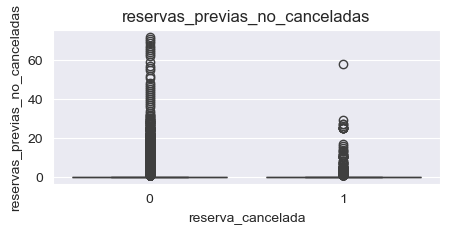

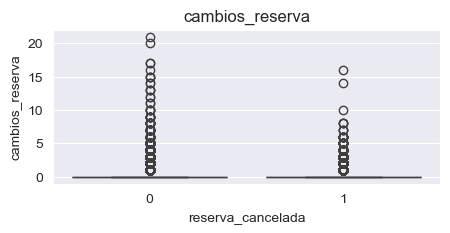

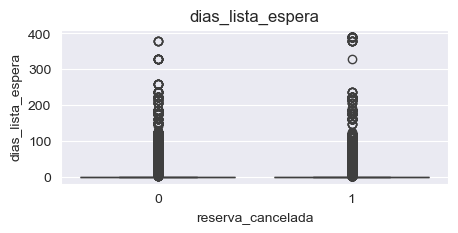

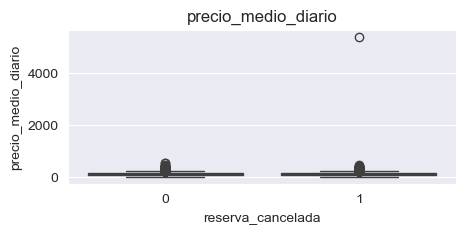

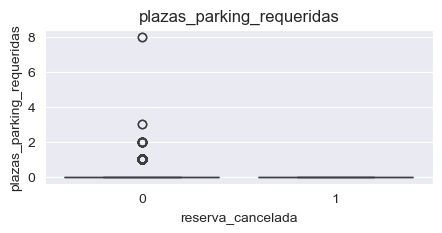

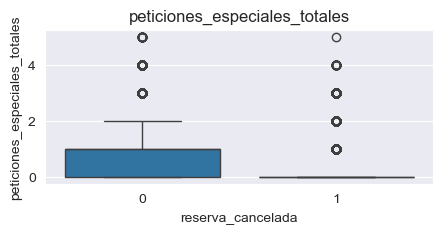

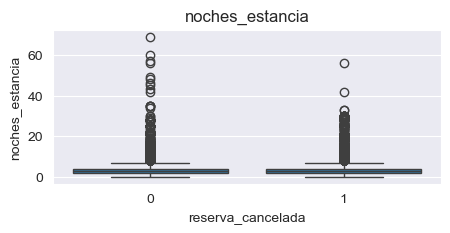

In [ ]:
import seaborn as sns
sns.set_style("darkgrid")
train = x_train.copy()
train["reserva_cancelada"] = y_train

for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(data=train,x="reserva_cancelada",y=col)
    plt.title(col)
    plt.show()

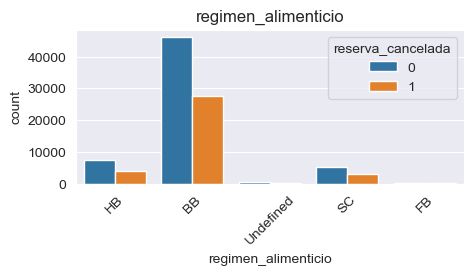

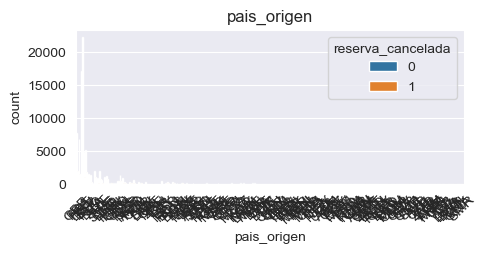

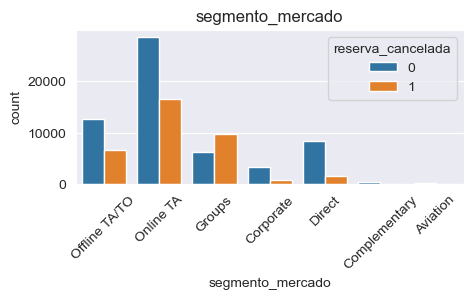

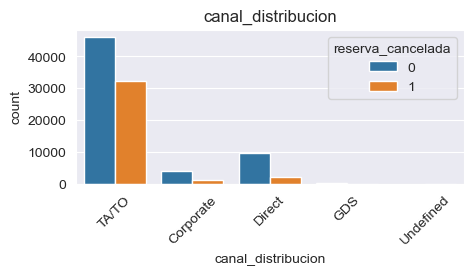

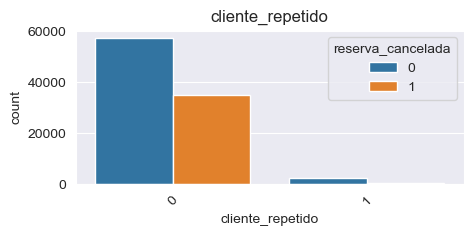

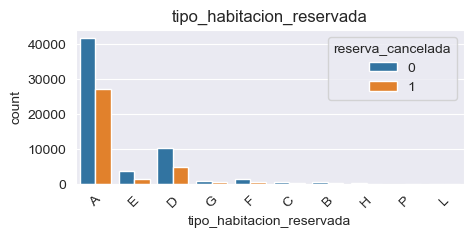

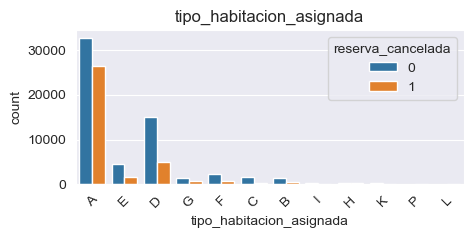

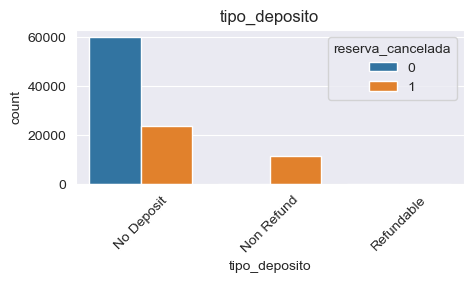

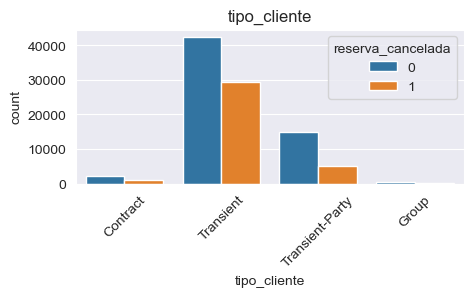

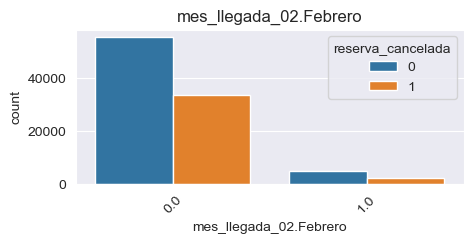

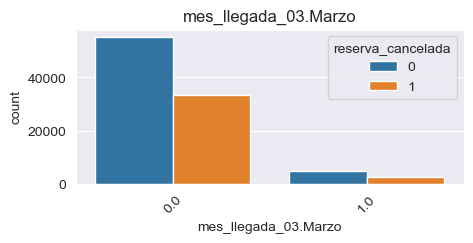

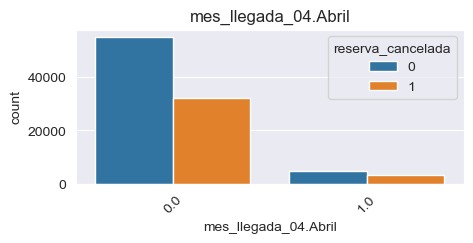

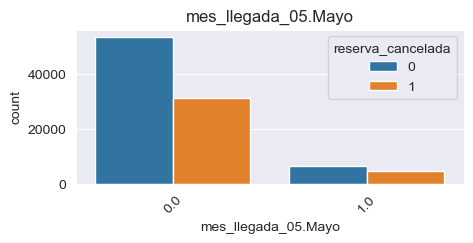

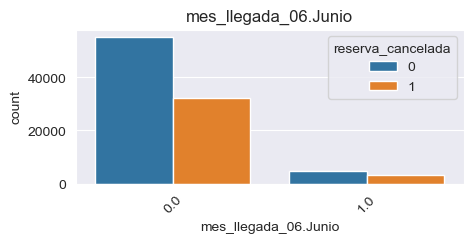

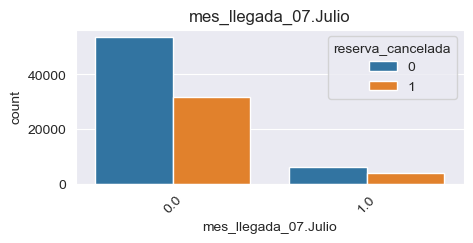

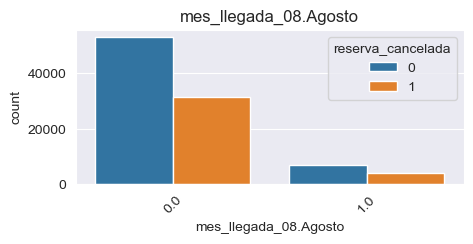

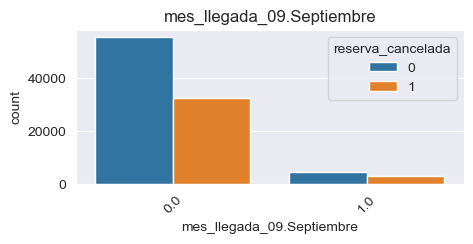

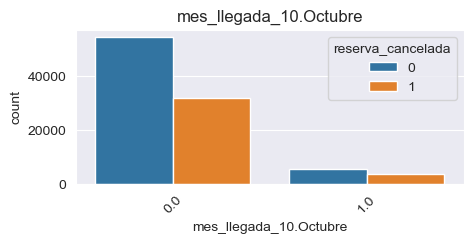

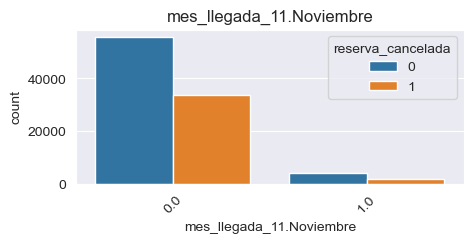

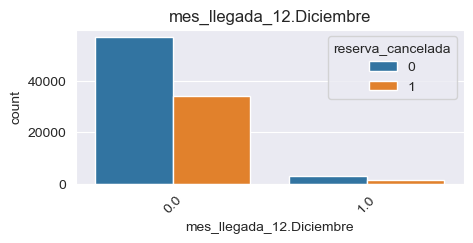

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(5,2))
    sns.countplot(data=train,x=col,hue="reserva_cancelada")
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

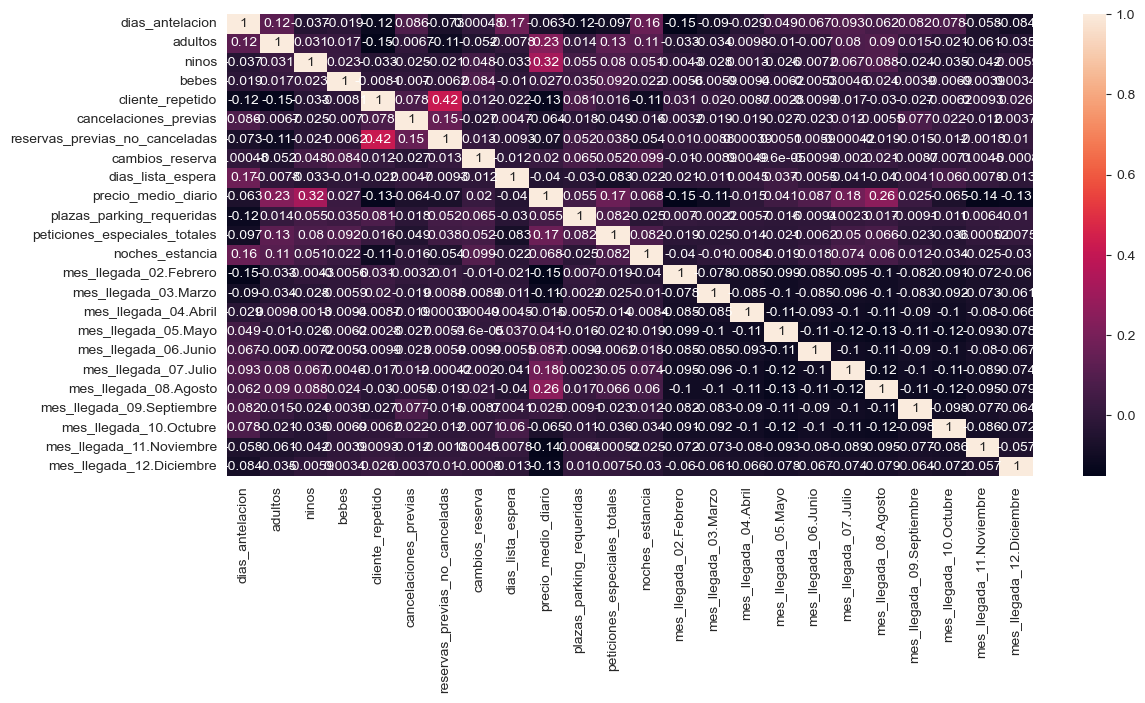

In [ ]:
plt.figure(figsize=(13,6))
sns.heatmap(x_train.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
x_train.describe()

,dias_antelacion,adultos,ninos,bebes,cliente_repetido,cancelaciones_previas,reservas_previas_no_canceladas,cambios_reserva,dias_lista_espera,precio_medio_diario,plazas_parking_requeridas,peticiones_especiales_totales,noches_estancia,mes_llegada_02.Febrero,mes_llegada_03.Marzo,mes_llegada_04.Abril,mes_llegada_05.Mayo,mes_llegada_06.Junio,mes_llegada_07.Julio,mes_llegada_08.Agosto,mes_llegada_09.Septiembre,mes_llegada_10.Octubre,mes_llegada_11.Noviembre,mes_llegada_12.Diciembre
count,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000
mean,104.129544,1.855851,0.103558,0.007695,0.031671,0.087225,0.136653,0.221302,2.331016,101.855850,0.062652,0.572274,3.423476,0.071331,0.072567,0.085099,0.113588,0.085330,0.104531,0.116226,0.080430,0.098092,0.063751,0.045345
std,107.005596,0.570659,0.398123,0.097789,0.175125,0.844994,1.483339,0.653950,17.755356,51.165925,0.245939,0.793298,2.556111,0.257379,0.259425,0.279031,0.317312,0.279373,0.305950,0.320498,0.271959,0.297441,0.244310,0.208061
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,69.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.800000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,161.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,737.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,69.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
x_train.loc[x_train['precio_medio_diario'] < 0, 'precio_medio_diario'].value_counts().sort_index()

precio_medio_diario
-6.38    1
Name: count, dtype: int64

In [ ]:
x_train['total_huespedes'] = (x_train['adultos'] + x_train['ninos'] + x_train['bebes'])
x_test['total_huespedes'] = (x_test['adultos'] + x_test['ninos'] + x_test['bebes'])

In [ ]:
(x_train['total_huespedes'] == 0).sum()

np.int64(141)

In [ ]:
idx = x_train[x_train['total_huespedes'] == 0].index

x_train = x_train.drop(index=idx)
y_train = y_train.drop(index=idx)

In [ ]:
(x_test['total_huespedes'] == 0).sum()

np.int64(39)

In [ ]:
idx = x_test[x_test['total_huespedes'] == 0].index

x_test = x_test.drop(index=idx)
y_test = y_test.drop(index=idx)

# Las variables 'adultos', 'ninos' y 'bebes' se sustituyen por la variable 'total_huespedes' para evitar redundancia y posibles problemas de multicolinealidad en el modelo de regresión logística.
x_train.drop(columns=['adultos', 'ninos', 'bebes'], inplace=True)
x_test.drop(columns=['adultos', 'ninos', 'bebes'], inplace=True)

In [ ]:
x_train["pais_origen"].value_counts()

pais_origen
PRT    39200
GBR     9680
FRA     8368
ESP     6851
DEU     5851
       ...  
SDN        1
BFA        1
KHM        1
NAM        1
SMR        1
Name: count, Length: 170, dtype: int64

In [ ]:
continentes = {
    'PRT':'Europa','GBR':'Europa','FRA':'Europa','ESP':'Europa',
    'DEU':'Europa','ITA':'Europa','IRL':'Europa','BEL':'Europa',
    'NLD':'Europa','CHE':'Europa','AUT':'Europa','SWE':'Europa',
    'POL':'Europa','RUS':'Europa','NOR':'Europa','ROU':'Europa',
    'DNK':'Europa','FIN':'Europa','LUX':'Europa','HUN':'Europa',
    'CZE':'Europa','GRC':'Europa','SRB':'Europa','HRV':'Europa',
    'EST':'Europa','LTU':'Europa','BGR':'Europa','UKR':'Europa',
    'SVK':'Europa','SVN':'Europa','CYP':'Europa','LVA':'Europa',
    'ISL':'Europa','BLR':'Europa','GIB':'Europa','MLT':'Europa',
    'BIH':'Europa','MKD':'Europa','ALB':'Europa','AND':'Europa',
    'FRO':'Europa','MNE':'Europa','JEY':'Europa','GGY':'Europa',
    'LIE':'Europa','SMR':'Europa','MCO':'Europa','IMN':'Europa',
    'CN':'Asia','CHN':'Asia','ISR':'Asia','TUR':'Asia','JPN':'Asia',
    'IND':'Asia','KOR':'Asia','IRN':'Asia','THA':'Asia','ARE':'Asia',
    'TWN':'Asia','SAU':'Asia','SGP':'Asia','PHL':'Asia','IDN':'Asia',
    'LBN':'Asia','HKG':'Asia','MYS':'Asia','KAZ':'Asia','GEO':'Asia',
    'OMN':'Asia','JOR':'Asia','KWT':'Asia','MAC':'Asia','BGD':'Asia',
    'QAT':'Asia','IRQ':'Asia','PAK':'Asia','AZE':'Asia','TJK':'Asia',
    'MDV':'Asia','LKA':'Asia','ARM':'Asia','UZB':'Asia','SYR':'Asia',
    'LAO':'Asia','NPL':'Asia','TMP':'Asia','MMR':'Asia','KHM':'Asia',
    'AGO':'África','MAR':'África','DZA':'África','ZAF':'África',
    'MOZ':'África','TUN':'África','NGA':'África','EGY':'África',
    'CPV':'África','SEN':'África','CMR':'África','LBY':'África',
    'KEN':'África','MUS':'África','CAF':'África','CIV':'África',
    'GHA':'África','TZA':'África','BEN':'África','GAB':'África',
    'ETH':'África','COM':'África','SYC':'África','ZMB':'África',
    'STP':'África','RWA':'África','MWI':'África','UGA':'África',
    'TGO':'África','MRT':'África','DJI':'África','MLI':'África',
    'SDN':'África','BFA':'África','NAM':'África','BWA':'África',
    'ZWE':'África','GNB':'África',
    'BRA':'América','USA':'América','ARG':'América','MEX':'América',
    'COL':'América','CHL':'América','PER':'América','VEN':'América',
    'URY':'América','ECU':'América','CRI':'América','PRI':'América',
    'BOL':'América','DOM':'América','PAN':'América','CUB':'América',
    'GTM':'América','SUR':'América','PRY':'América','JAM':'América',
    'SLV':'América','ABW':'América','AIA':'América','GUY':'América',
    'VGB':'América','DMA':'América','BHS':'América','LCA':'América',
    'NIC':'América','KNA':'América','CYM':'América','ASM':'América',
    'BRB':'América','GLP':'América',
    'AUS':'Oceanía','NZL':'Oceanía','FJI':'Oceanía','KIR':'Oceanía',
    'PYF':'Oceanía','UMI':'Oceanía',
    'ATA':'Antártida'}

In [ ]:
x_train["continente"] = (x_train["pais_origen"].map(continentes).fillna("Otros"))
x_test["continente"] = (x_test["pais_origen"].map(continentes).fillna("Otros"))
x_train.drop(columns="pais_origen", inplace=True)
x_test.drop(columns="pais_origen", inplace=True)

In [ ]:
x_train['coincide_habitacion'] = (x_train['tipo_habitacion_reservada'] == x_train['tipo_habitacion_asignada']).astype(int)
x_test['coincide_habitacion'] = (x_test['tipo_habitacion_reservada'] == x_test['tipo_habitacion_asignada']).astype(int)

x_train.drop(columns=["tipo_habitacion_reservada","tipo_habitacion_asignada"], inplace=True)
x_test.drop(columns=["tipo_habitacion_reservada","tipo_habitacion_asignada"], inplace=True)

In [ ]:
#Incluyo por ahora las que voy a codificar en dummy

#dias_antelacion, tipo_deposito, cliente_repetido, segmento_mercado, peticiones_especiales_totales,
#cancelaciones_previas y reservas_previas_no_canceladas

mod_cols = ["continente","regimen_alimenticio","segmento_mercado","tipo_deposito","canal_distribucion","tipo_cliente"]

In [ ]:
encoder = OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)
train_encoded = encoder.fit_transform(x_train[mod_cols])

test_encoded = encoder.transform(x_test[mod_cols])
encoded_cols = encoder.get_feature_names_out(mod_cols)

train_encoded = pd.DataFrame(train_encoded,columns=encoded_cols,index=x_train.index)
test_encoded = pd.DataFrame(test_encoded,columns=encoded_cols,index=x_test.index)

x_train.drop(columns=mod_cols, inplace=True)
x_test.drop(columns=mod_cols, inplace=True)

x_train = pd.concat([x_train, train_encoded],axis=1)
x_test = pd.concat([x_test, test_encoded],axis=1)

In [ ]:
X = x_train.copy()
X = sm.add_constant(X)
for ii, col in enumerate(X.columns):
    vif = variance_inflation_factor(X.values,ii)
    print(f"{col}: {vif:.2f}")

const: 592.20
dias_antelacion: 1.63
cliente_repetido: 1.35
cancelaciones_previas: 1.09
reservas_previas_no_canceladas: 1.29
cambios_reserva: 1.06
dias_lista_espera: 1.06
precio_medio_diario: 1.71
plazas_parking_requeridas: 1.06
peticiones_especiales_totales: 1.28
noches_estancia: 1.19
mes_llegada_02.Febrero: 1.98
mes_llegada_03.Marzo: 1.99
mes_llegada_04.Abril: 2.19
mes_llegada_05.Mayo: 2.59
mes_llegada_06.Junio: 2.29
mes_llegada_07.Julio: 2.62
mes_llegada_08.Agosto: 2.81
mes_llegada_09.Septiembre: 2.22
mes_llegada_10.Octubre: 2.40
mes_llegada_11.Noviembre: 1.89
mes_llegada_12.Diciembre: 1.64
total_huespedes: 1.28
coincide_habitacion: 1.10
continente_Antártida: 1.00
continente_Asia: 1.83
continente_Europa: 2.18
continente_Oceanía: 1.10
continente_Otros: 1.00
continente_África: 1.23
regimen_alimenticio_FB: 1.05
regimen_alimenticio_HB: 1.16
regimen_alimenticio_SC: 1.15
regimen_alimenticio_Undefined: 1.07
segmento_mercado_Complementary: 4.48
segmento_mercado_Corporate: 22.22
segmento_merc

In [ ]:
x_train.drop(columns=["segmento_mercado_Online TA","segmento_mercado_Direct","canal_distribucion_TA/TO","tipo_cliente_Transient-Party"], inplace=True)
x_test.drop(columns=["segmento_mercado_Online TA","segmento_mercado_Direct","canal_distribucion_TA/TO","tipo_cliente_Transient-Party"], inplace=True)

In [ ]:
X = x_train.copy()
X = sm.add_constant(X)
for ii, col in enumerate(X.columns):
    vif = variance_inflation_factor(X.values,ii)
    print(f"{col}: {vif:.2f}")

const: 67.56
dias_antelacion: 1.62
cliente_repetido: 1.34
cancelaciones_previas: 1.09
reservas_previas_no_canceladas: 1.29
cambios_reserva: 1.06
dias_lista_espera: 1.06
precio_medio_diario: 1.71
plazas_parking_requeridas: 1.06
peticiones_especiales_totales: 1.27
noches_estancia: 1.15
mes_llegada_02.Febrero: 1.98
mes_llegada_03.Marzo: 1.99
mes_llegada_04.Abril: 2.18
mes_llegada_05.Mayo: 2.59
mes_llegada_06.Junio: 2.29
mes_llegada_07.Julio: 2.62
mes_llegada_08.Agosto: 2.80
mes_llegada_09.Septiembre: 2.21
mes_llegada_10.Octubre: 2.39
mes_llegada_11.Noviembre: 1.89
mes_llegada_12.Diciembre: 1.64
total_huespedes: 1.27
coincide_habitacion: 1.10
continente_Antártida: 1.00
continente_Asia: 1.83
continente_Europa: 2.17
continente_Oceanía: 1.10
continente_Otros: 1.00
continente_África: 1.23
regimen_alimenticio_FB: 1.05
regimen_alimenticio_HB: 1.15
regimen_alimenticio_SC: 1.14
regimen_alimenticio_Undefined: 1.06
segmento_mercado_Complementary: 1.09
segmento_mercado_Corporate: 1.37
segmento_mercad

# Explicación de las nuevas features o las transformaciones realizadas
Durante la exploración he detectado valores extremos en algunas variables numéricas (ej: "dias_antelacion" y "precio_medio_diario"). Sin embargo, no los he borrado porque son plausibles en la hostelería y no parecen errores de registro. He decidido mantenerlos para no eliminar observaciones reales y reducir la variabilidad de los datos.

En los histogramas por clase he observado que dias_antelacion, tipo_deposito, cliente_repetido, segmento_mercado, peticiones_especiales_totales, cancelaciones_previas y reservas_previas_no_canceladas tienen potencial como variables predictoras por u potencial discriminativo.

Tras hacer los plots, he revisado el conjunto de datos para comprobar las variables. Por un lado, precio_medio_diario tenía un valor mínimo negativo, por lo que revisé si había más valores por debajo de 0. Sólo encontré uno, y como podía deberse a un reembolso, lo dejé.

Por otro lado, vi que había registros donde "no había huéspedes (ni adultos, ni bebés, ni niños). Calculé "total_huespedes" para cuantificar los registros sin huéspedes y borrarlos, ya que no serían datos válidos.

Seguidamente revisé la variable pais_origen. Había muchos países con pocos registros, así que he recodificado con onehotencoder cada país en su continente correspondiente, lo que reduce la lista de países a 6 variables dummy.

He continuado la recodificación en variables dummy de "regimen_alimenticio", "segmento_mercado", "canal_distribucion", "tipo_habitacion_reservada", "tipo_habitacion_asignada", "tipo_deposito" y "tipo_cliente" para disponer de valores numéricos dummy que faciliten el análisis posterior de las features en los modelos de regresión. Luego he borrado las variables originales y he dejado las recodificadas.

También he creado "coincide_habitación" para indicar si la habitación reservada corresponde a la asignada (1) o no (0). Me ha parecido una variable de interés para el modelo.

He realizado análisis de multicolinealidad con vif y he analizado las variables que podían añadir multicolinealidad al modelo. He ido quitándolas una a una, hasta alcanzar valores por debajo de 5 de las variables restantes.

In [ ]:
cat_cols = ["cliente_repetido","mes_llegada_02.Febrero","mes_llegada_03.Marzo","mes_llegada_04.Abril","mes_llegada_05.Mayo",
    "mes_llegada_06.Junio","mes_llegada_07.Julio","mes_llegada_08.Agosto","mes_llegada_09.Septiembre","mes_llegada_10.Octubre",
    "mes_llegada_11.Noviembre","mes_llegada_12.Diciembre","coincide_habitacion","continente_Antártida","continente_Asia",
    "continente_Europa","continente_Oceanía","continente_Otros","continente_África","regimen_alimenticio_FB","regimen_alimenticio_HB",
    "regimen_alimenticio_SC","regimen_alimenticio_Undefined","segmento_mercado_Complementary","segmento_mercado_Corporate",
    "segmento_mercado_Groups","segmento_mercado_Offline TA/TO","tipo_deposito_Non Refund","tipo_deposito_Refundable",
    "canal_distribucion_Direct","canal_distribucion_GDS","canal_distribucion_Undefined","tipo_cliente_Group","tipo_cliente_Transient"]

num_cols = ["dias_antelacion","cancelaciones_previas","reservas_previas_no_canceladas","cambios_reserva",
            "dias_lista_espera","precio_medio_diario","plazas_parking_requeridas","peticiones_especiales_totales","noches_estancia","total_huespedes"]

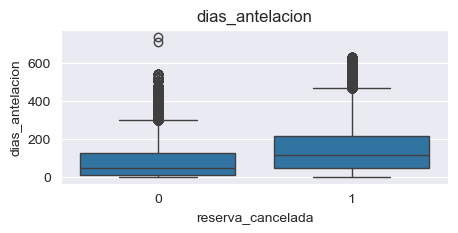

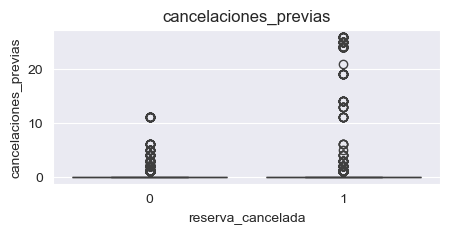

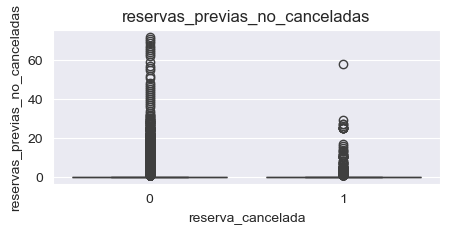

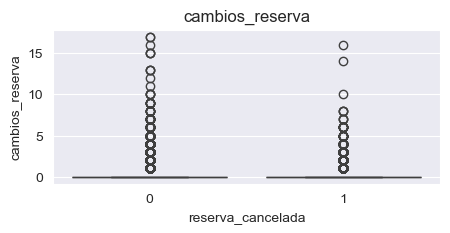

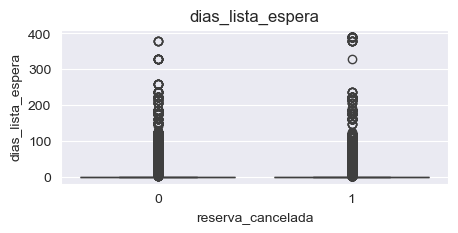

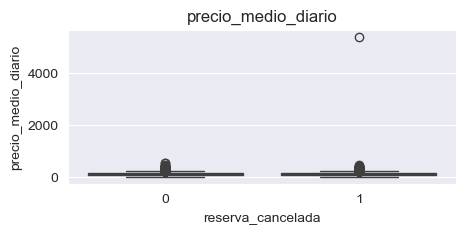

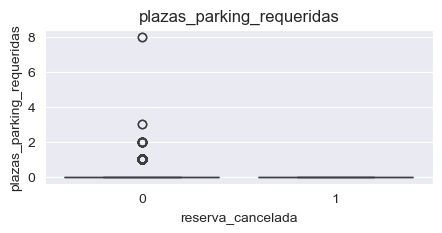

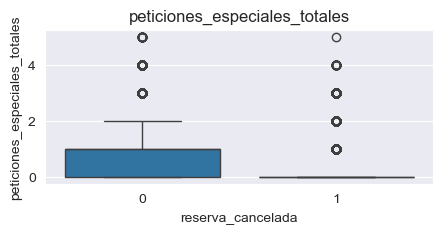

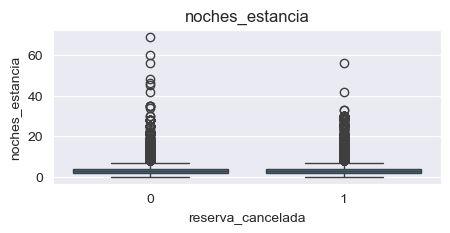

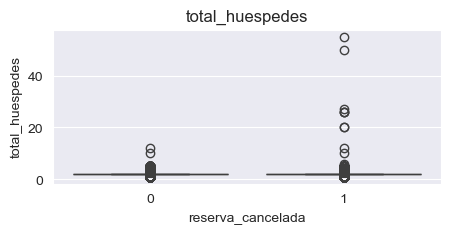

In [ ]:
train = x_train.copy()
train["reserva_cancelada"] = y_train

for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(data=train,x="reserva_cancelada",y=col)
    plt.title(col)
    plt.show()

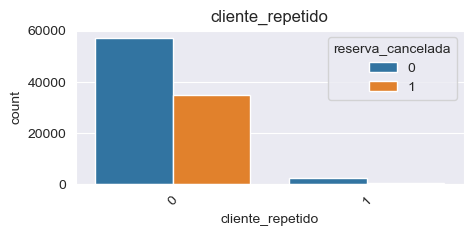

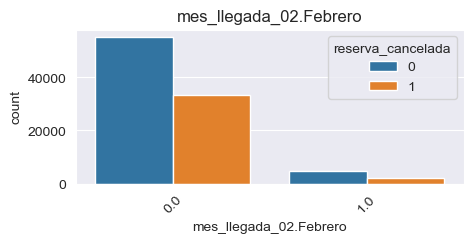

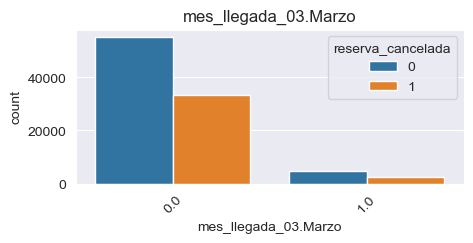

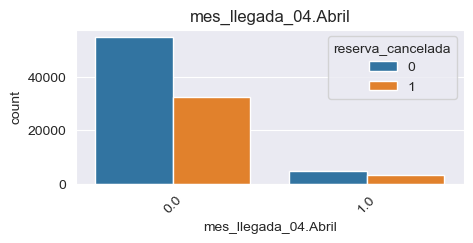

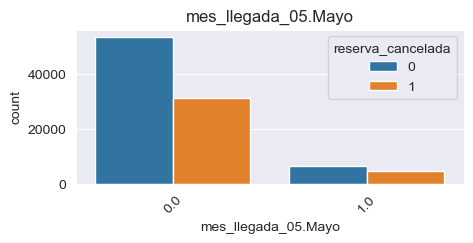

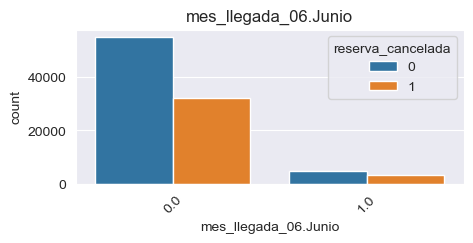

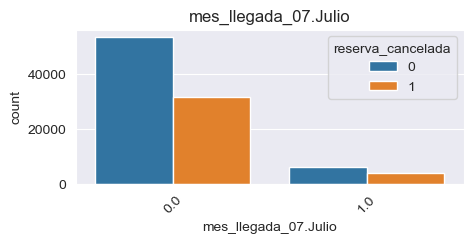

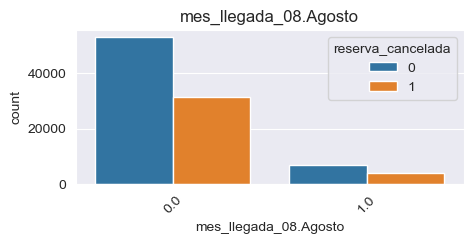

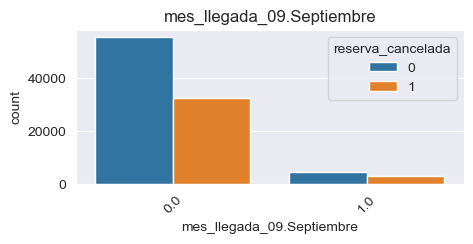

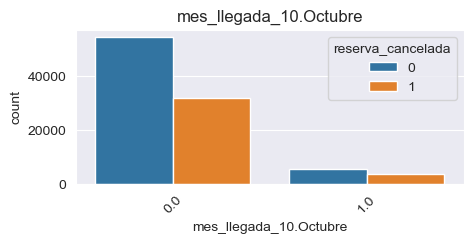

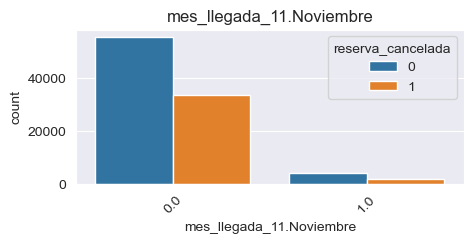

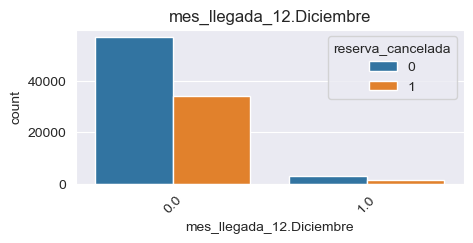

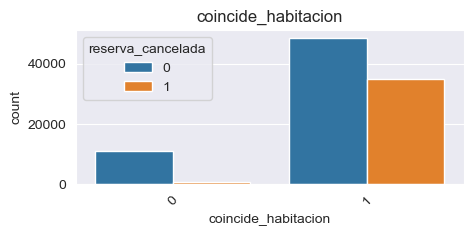

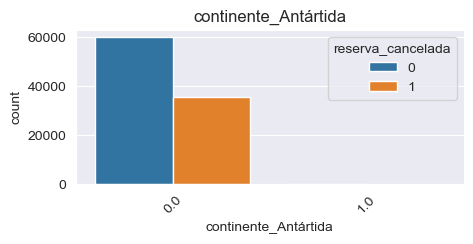

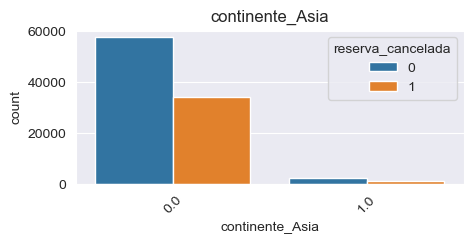

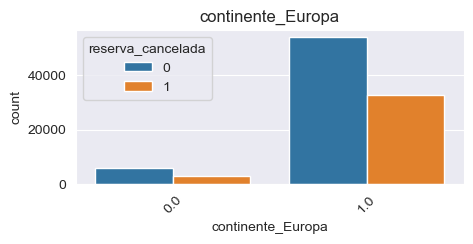

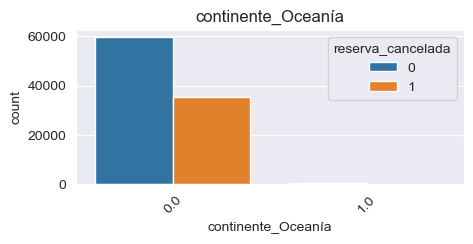

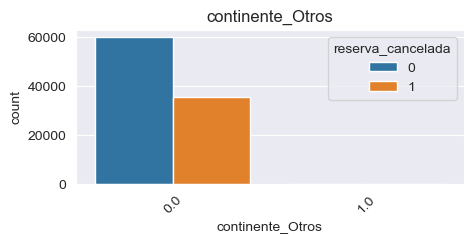

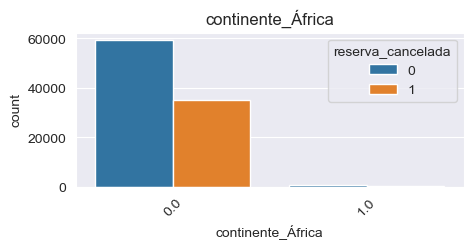

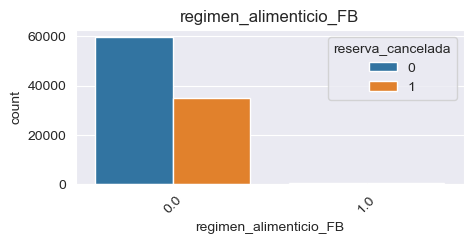

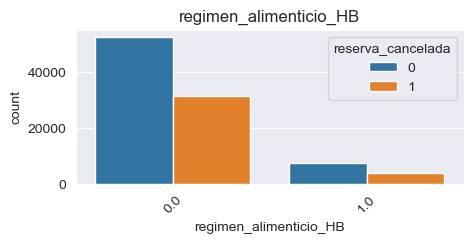

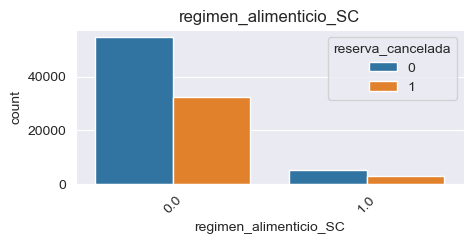

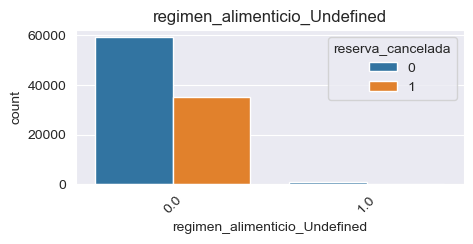

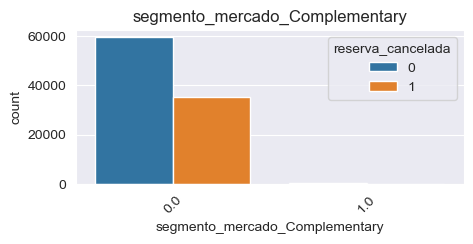

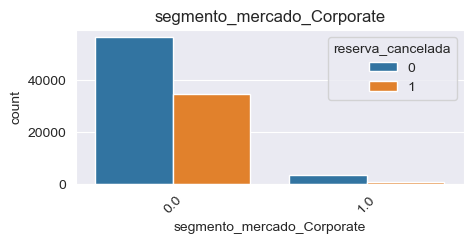

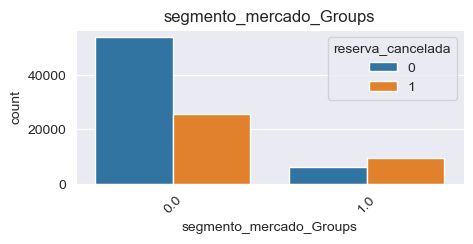

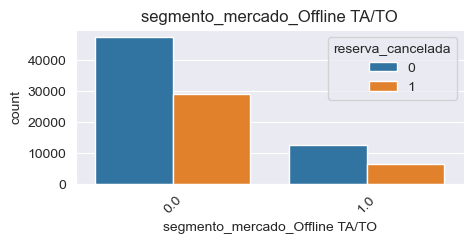

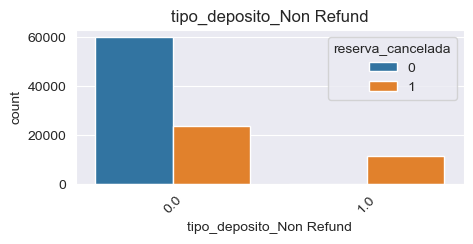

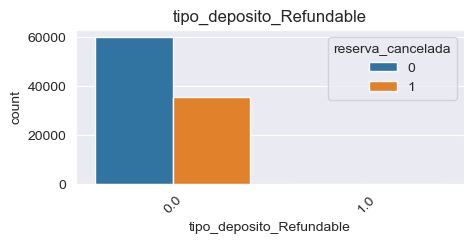

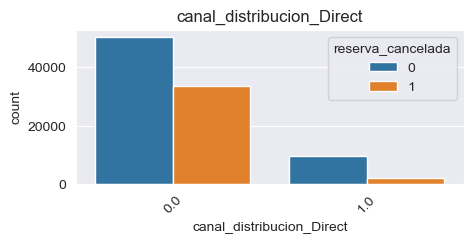

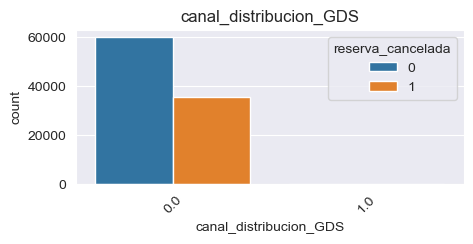

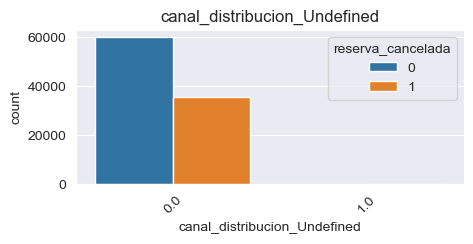

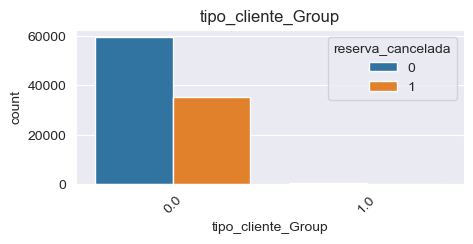

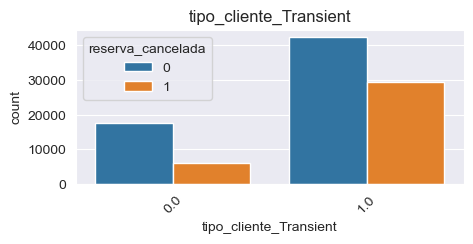

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(5,2))
    sns.countplot(data=train,x=col,hue="reserva_cancelada")
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

# Parte 2: Modelo Explicativo

Se realiza un modelo explicativo con el conjunto de train.

In [ ]:
#Es el primer modelo de regresión logística. He optado por incluir todas las variables e ir retirando poco a poco hasta ajustar el modelo. Por tanto, en este primer modelo están todas las features. El ajuste es muy malo.

X = x_train
X = sm.add_constant(X, has_constant="add")
y = y_train.astype(float).copy()

model = sm.Logit(y, X)
results = model.fit(method="lbfgs",maxiter=1000,disp=True)

print(results.summary())

                           Logit Regression Results                           
Dep. Variable:      reserva_cancelada   No. Observations:                95371
Model:                          Logit   Df Residuals:                    95326
Method:                           MLE   Df Model:                           44
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                -0.04985
Time:                        11:40:37   Log-Likelihood:                -66106.
converged:                       True   LL-Null:                       -62967.
Covariance Type:            nonrobust   LLR p-value:                     1.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                                   0      0.053          0      1.000      -0.104       0.104
dias_antelacion                         0    7.7e-05          0      1.

In [ ]:
#Primero he quitado las tres variables cuyos coeficientes eran menores a 0.00...
#Esto ha mejorado mucho el ajuste.

X = x_train.drop(columns=["dias_antelacion","dias_lista_espera","precio_medio_diario"])
X = sm.add_constant(X, has_constant="add")
y = y_train.astype(float).copy()

model = sm.Logit(y, X)
results = model.fit(method="lbfgs",maxiter=1000,disp=True)

print(results.summary())

                           Logit Regression Results                           
Dep. Variable:      reserva_cancelada   No. Observations:                95371
Model:                          Logit   Df Residuals:                    95329
Method:                           MLE   Df Model:                           41
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                  0.3579
Time:                        11:40:43   Log-Likelihood:                -40431.
converged:                       True   LL-Null:                       -62967.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -2.9108      0.079    -37.008      0.000      -3.065      -2.757
cliente_repetido                  -0.7787      0.094     -8.291      0.

In [ ]:
#Posteriormente he retirado las variables con p mayor a 0.1. El ajuste es prácticamente el mismo, pero hay menos ruido de variables en el modelo.

X = x_train.drop(columns=["dias_antelacion","dias_lista_espera","precio_medio_diario","mes_llegada_03.Marzo","mes_llegada_09.Septiembre",
                          "continente_Antártida","continente_Otros","regimen_alimenticio_SC",
                          "segmento_mercado_Complementary","canal_distribucion_Undefined"])
X = sm.add_constant(X, has_constant="add")
y = y_train.astype(float).copy()

model = sm.Logit(y, X)
results = model.fit(method="lbfgs",maxiter=1000,disp=True)

print(results.summary())

                           Logit Regression Results                           
Dep. Variable:      reserva_cancelada   No. Observations:                95371
Model:                          Logit   Df Residuals:                    95336
Method:                           MLE   Df Model:                           34
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                  0.3578
Time:                        11:40:46   Log-Likelihood:                -40437.
converged:                       True   LL-Null:                       -62967.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -2.9191      0.073    -40.239      0.000      -3.061      -2.777
cliente_repetido                  -0.7756      0.094     -8.263      0.

Modelo de referencia. En la última de vuestras celdas dejad claro cuál es el modelo final de referencia a continuación.

In [ ]:
#He analizado el aic y el bic para ver si podía ajustar un poquito más el modelo. En el siguiente modelo he excluido la variable cuyos valores
#en el intervalo de confianza contenían el 0 entre ellos.Primero quité Continente Europa. Al hacerlo, el nuevo modelo mostraba otra variable con
#el valor 0 dentro de su intervalo de confianza: Continente Asia. Es por ello que he quitado ambos. El bic se ha reducido en consecuencia.
print(results.aic)
print(results.bic)

80944.49780544039
81275.79134942024


In [ ]:
X2 = X.drop(columns=["continente_Europa","continente_Asia"])

model2 = sm.Logit(y, X2)
results2 = model2.fit(method="lbfgs",maxiter=1000,disp=True)

print(results2.summary())
print(results2.aic)
print(results2.bic)

                           Logit Regression Results                           
Dep. Variable:      reserva_cancelada   No. Observations:                95371
Model:                          Logit   Df Residuals:                    95338
Method:                           MLE   Df Model:                           32
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                  0.3578
Time:                        11:40:49   Log-Likelihood:                -40440.
converged:                       True   LL-Null:                       -62967.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -2.8511      0.062    -45.906      0.000      -2.973      -2.729
cliente_repetido                  -0.7774      0.094     -8.280      0.

In [ ]:
#Finalmente he calculado los odds ratio para entender mejor el impacto de cada variable en la target.
cnf = results2.conf_int()
cnf.columns = ['IC_inf', 'IC_sup']

x_train_results = pd.DataFrame({
    "coef": results2.params,
    "OR": np.exp(results2.params),
    "IC_inf": np.exp(cnf['IC_inf']),
    "IC_sup": np.exp(cnf['IC_sup']),
    "p-value": results2.pvalues})
x_train_results.drop('const').round(3)

,coef,OR,IC_inf,IC_sup,p-value
cliente_repetido,-0.777,0.460,0.382,0.552,0.000
cancelaciones_previas,2.883,17.874,15.639,20.428,0.000
reservas_previas_no_canceladas,-0.545,0.580,0.546,0.615,0.000
cambios_reserva,-0.327,0.721,0.698,0.746,0.000
plazas_parking_requeridas,-33.790,0.000,0.000,0.000,0.000
peticiones_especiales_totales,-0.676,0.509,0.496,0.522,0.000
noches_estancia,0.055,1.056,1.049,1.063,0.000
mes_llegada_02.Febrero,-0.089,0.915,0.848,0.987,0.021
mes_llegada_04.Abril,0.114,1.121,1.046,1.200,0.001
mes_llegada_05.Mayo,0.190,1.209,1.137,1.286,0.000


# Conclusiones
# - Conclusión 1: Interpretación del modelo:
El modelo de regresión logística obtenido es significativo (LLR p < 0.001) y tiene un Pseudo R² de 0.358, lo que indica un buen ajuste para este tipo de modelos. El algoritmo converge correctamente y los criterios AIC (80 945.37) y BIC (81 257.74) muestran un equilibrio adecuado en capacidad explicativa-complejidad del modelo.
Los features incluidos en el modelo son estadísticamente significativos al nivel (p < 0.05), lo que indica que predicen la probabilidad de cancelación de una reserva.
    
# - Conclusión 2: Features más relevantes del modelo:
El tipo de depósito no reembolsable es el mayor predictor de la cancelación, con una probabilidad del 305% de cancelar la reserva si el tipo de depósito es de esta naturaleza.
Después de esta variable, el comportamiento previo del cliente es el principal determinante de las cancelaciones. Cada cancelación previa multiplica por 17,9 las probabilidades de volver a cancelar (OR = 17.87). Cada reserva previa no cancelada reduce dichas probabilidades aproximadamente un 42 % (OR = 0.58). Los clientes que han repetido reserva presentan unas probabilidades de cancelación aproximadamente un 54 % inferiores a las de los clientes nuevos (OR = 0.46).

# - Conclusión 3: Complejidad de la reserva:
Cuantas más peticiones especiales hace el cliente, menos probable es que cancele la reserva. Cada petición especial reduce las probabilidades de cancelación aproximadamente un 49 % (OR = 0.51) y cada modificación de la reserva reduce dichas probabilidades cerca de un 28 % (OR = 0.72). Estos resultados sugieren que los clientes que interactúan más con su reserva presentan una mayor intención de completar su estancia.

# - Conclusión 4: origen de la reserva:
El origen comercial de la reserva constituye un factor relevante para explicar el comportamiento de cancelación. El segmento_mercado_Offline TA/TO reduce las probabilidades de cancelación aproximadamente un 72 % (OR = 0.28). El segmento_mercado_Corporate reduce las probabilidades alrededor de un 58 % (OR = 0.42) y el canal_distribucion_Direct reduce las probabilidades aproximadamente un 67 % (OR = 0.33).

# - Conclusión 5:
Las reservas realizadas para los meses de abril, mayo, junio, julio, agosto, octubre y diciembre presentan una mayor probabilidad de cancelación que el mes de referencia (enero), mientras que febrero y noviembre muestran una probabilidad ligeramente inferior. Cada huésped adicional incrementa las probabilidades de cancelación aproximadamente un 27 % (OR = 1.27).

# Parte 3: Modelo Predictivo

Se realiza el modelo predictivo que entrenaré con el conjunto de train.

In [ ]:
num_cols = ["dias_antelacion","cancelaciones_previas","reservas_previas_no_canceladas","cambios_reserva",
            "dias_lista_espera","precio_medio_diario","plazas_parking_requeridas","peticiones_especiales_totales",
            "noches_estancia","total_huespedes"]

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

scaler = StandardScaler()

x_train_scaled[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test_scaled[num_cols] = scaler.transform(x_test[num_cols])
x_train_scaled.head()

,dias_antelacion,cliente_repetido,cancelaciones_previas,reservas_previas_no_canceladas,cambios_reserva,dias_lista_espera,precio_medio_diario,plazas_parking_requeridas,peticiones_especiales_totales,noches_estancia,mes_llegada_02.Febrero,mes_llegada_03.Marzo,mes_llegada_04.Abril,mes_llegada_05.Mayo,mes_llegada_06.Junio,mes_llegada_07.Julio,mes_llegada_08.Agosto,mes_llegada_09.Septiembre,mes_llegada_10.Octubre,mes_llegada_11.Noviembre,mes_llegada_12.Diciembre,total_huespedes,coincide_habitacion,continente_Antártida,continente_Asia,continente_Europa,continente_Oceanía,continente_Otros,continente_África,regimen_alimenticio_FB,regimen_alimenticio_HB,regimen_alimenticio_SC,regimen_alimenticio_Undefined,segmento_mercado_Complementary,segmento_mercado_Corporate,segmento_mercado_Groups,segmento_mercado_Offline TA/TO,tipo_deposito_Non Refund,tipo_deposito_Refundable,canal_distribucion_Direct,canal_distribucion_GDS,canal_distribucion_Undefined,tipo_cliente_Group,tipo_cliente_Transient
16209,0.773492,0,-0.103235,-0.092111,-0.343110,-0.13131,0.299773,-0.254807,-0.721463,1.411352,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.042135,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9077,-0.973938,0,-0.103235,-0.092111,-0.343110,-0.13131,-0.528546,-0.254807,-0.721463,-0.560556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.042135,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9623,-0.973938,0,-0.103235,-0.092111,-0.343110,-0.13131,-1.155170,-0.254807,-0.721463,-0.954938,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.362905,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
35214,0.184786,0,-0.103235,-0.092111,1.224221,-0.13131,-0.397151,-0.254807,-0.721463,1.411352,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.042135,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21972,-0.590811,0,-0.103235,-0.092111,1.224221,-0.13131,-0.450218,-0.254807,-0.721463,6.932695,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.042135,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


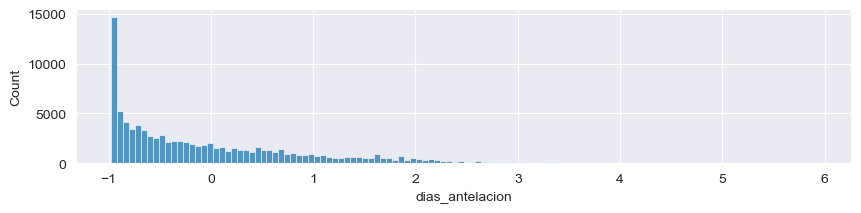

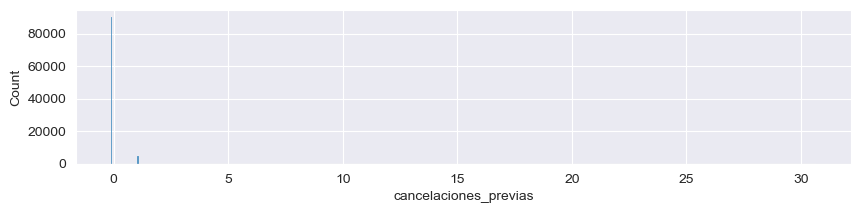

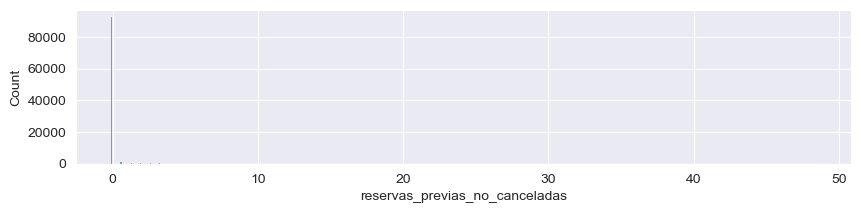

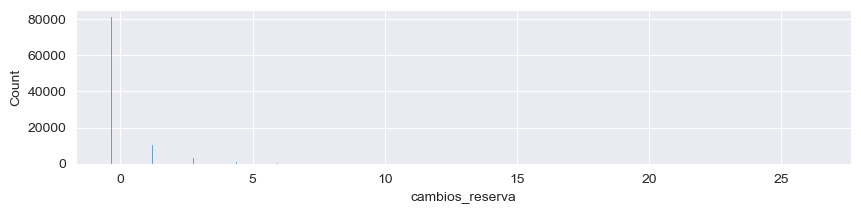

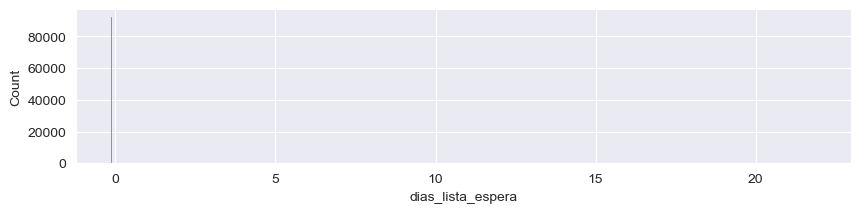

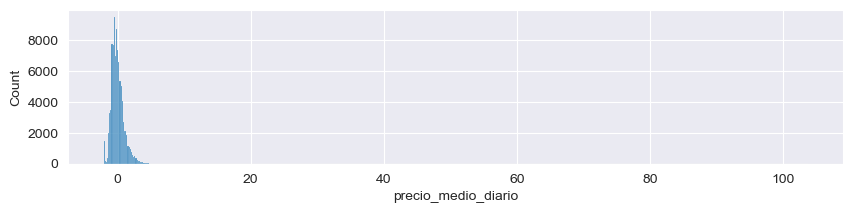

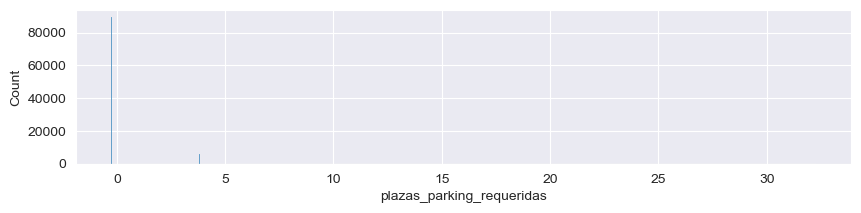

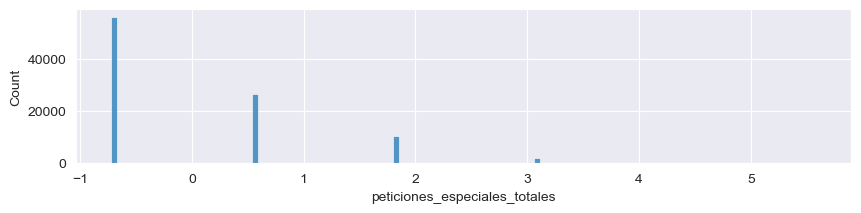

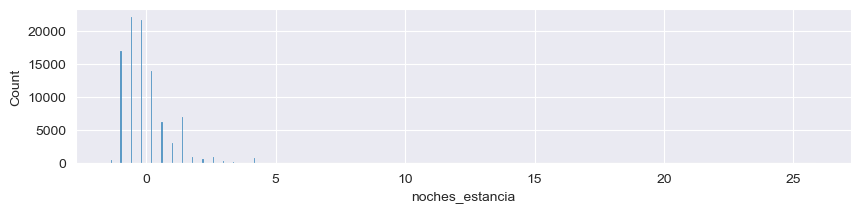

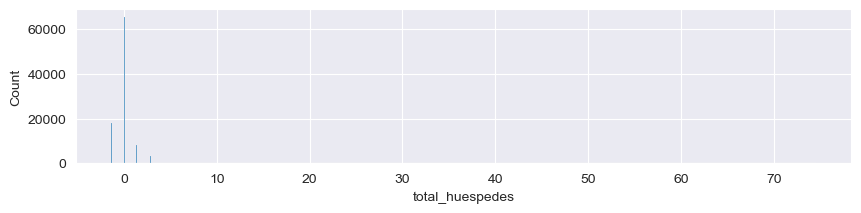

In [ ]:
for col in num_cols:
    plt.figure(figsize=(10,2))
    sns.histplot(data=x_train_scaled, x=col)
    plt.show()

In [ ]:
cont_cols = ["dias_antelacion","dias_lista_espera","precio_medio_diario","peticiones_especiales_totales"]

pt = PowerTransformer(method="yeo-johnson")
x_train_scaled[cont_cols] = pt.fit_transform(x_train_scaled[cont_cols])
x_test_scaled[cont_cols] = pt.transform(x_test_scaled[cont_cols])

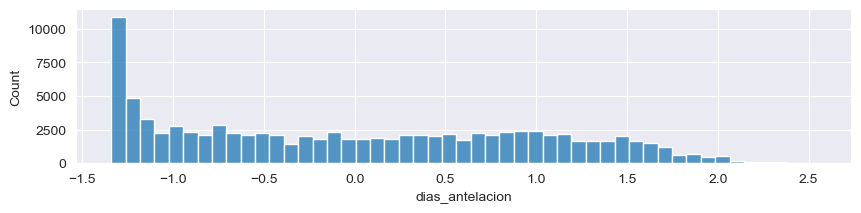

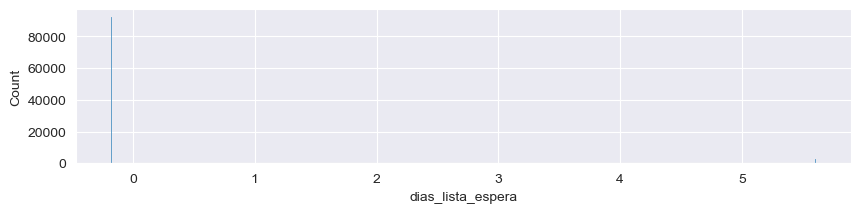

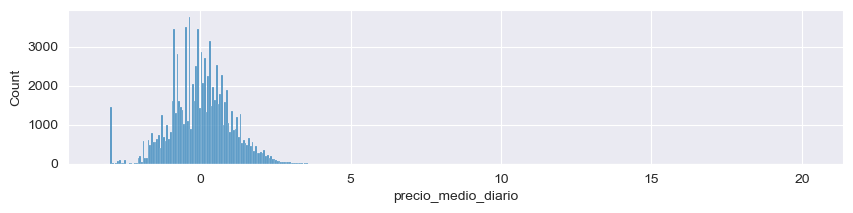

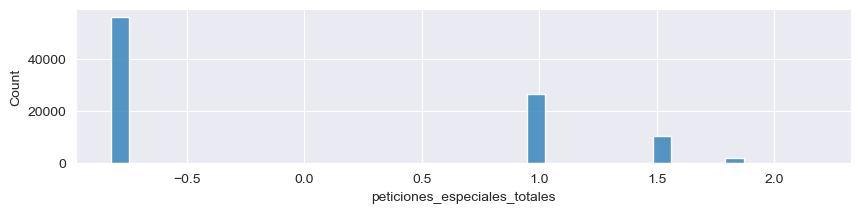

In [ ]:
for col in cont_cols:
    plt.figure(figsize=(10,2))
    sns.histplot(data=x_train_scaled, x=col)
    plt.show()

In [ ]:
cols_drop = ["dias_antelacion","dias_lista_espera","precio_medio_diario","mes_llegada_03.Marzo","mes_llegada_09.Septiembre",
                          "continente_Antártida","continente_Otros","regimen_alimenticio_SC",
                          "segmento_mercado_Complementary","canal_distribucion_Undefined","continente_Europa","continente_Asia"]

x_train2 = x_train_scaled.drop(columns=cols_drop)
x_test2 = x_test_scaled.drop(columns=cols_drop)

model = LogisticRegression(max_iter=1000,random_state=seed)
model.fit(x_train2, y_train)

y_hat_test = model.predict(x_test2)
y_prob_test = model.predict_proba(x_test2)[:,1]

print("Accuracy:", accuracy_score(y_test, y_hat_test))
print("AUC:", roc_auc_score(y_test, y_prob_test))

Accuracy: 0.8059482360837283
AUC: 0.8579674383941891


In [ ]:
cols_drop = ["dias_lista_espera","mes_llegada_03.Marzo","continente_Antártida","continente_Otros","regimen_alimenticio_SC",
                          "canal_distribucion_Undefined","continente_Europa"]

x_train2 = x_train_scaled.drop(columns=cols_drop)
x_test2 = x_test_scaled.drop(columns=cols_drop)

model = LogisticRegression(max_iter=1000, random_state=seed)
model.fit(x_train2, y_train)

y_hat_test = model.predict(x_test2)
y_prob_test = model.predict_proba(x_test2)[:,1]

print("Accuracy:", accuracy_score(y_test, y_hat_test))
print("AUC:", roc_auc_score(y_test, y_prob_test))

Accuracy: 0.8142959016737279
AUC: 0.8663208241488152


In [ ]:
y_hat_train = model.predict(x_train2)
y_prob_train = model.predict_proba(x_train2)[:, 1]

print(f"Train: Accuracy={accuracy_score(y_train, y_hat_train):.3f} | "f"AUC={roc_auc_score(y_train, y_prob_train):.3f}")
print(f"Test: Accuracy={accuracy_score(y_test, y_hat_test):.3f} | "f"AUC={roc_auc_score(y_test, y_prob_test):.3f}")

Train: Accuracy=0.817 | AUC=0.870
Test: Accuracy=0.814 | AUC=0.866


In [ ]:
print("\nRESULTADOS TRAIN")
print(f"Accuracy: {accuracy_score(y_train, y_hat_train):.3f}")
print(f"AUC: {roc_auc_score(y_train, y_prob_train):.3f}")

print("\nRESULTADOS TEST")
print(f"Accuracy: {accuracy_score(y_test, y_hat_test):.3f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_test):.3f}")
print(f"Precision: {precision_score(y_test, y_hat_test):.3f}")
print(f"Recall: {recall_score(y_test, y_hat_test):.3f}")
print(f"F1-score: {f1_score(y_test, y_hat_test):.3f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_hat_test))

print("\nClasificación:")
print(classification_report(y_test, y_hat_test))


RESULTADOS TRAIN
Accuracy: 0.817
AUC: 0.870

RESULTADOS TEST
Accuracy: 0.814
AUC: 0.866
Precision: 0.822
Recall: 0.625
F1-score: 0.710

Matriz de confusión:
[[13985  1174]
 [ 3253  5427]]

Clasificación:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86     15159
           1       0.82      0.63      0.71      8680

    accuracy                           0.81     23839
   macro avg       0.82      0.77      0.79     23839
weighted avg       0.82      0.81      0.81     23839



In [ ]:
cols_to_drop = ["dias_lista_espera","mes_llegada_03.Marzo","continente_Antártida","continente_Otros","regimen_alimenticio_SC",
                "canal_distribucion_Undefined","continente_Europa"]

x_train2 = x_train_scaled.drop(columns=cols_to_drop)
x_test2 = x_test_scaled.drop(columns=cols_to_drop)

model2 = LogisticRegression(penalty="l2",solver="lbfgs",max_iter=1000,random_state=seed)
model2.fit(x_train2, y_train)

y_hat_test = model2.predict(x_test2)
y_prob_test = model2.predict_proba(x_test2)[:,1]

print("RIDGE (L2)")
print("Accuracy:", accuracy_score(y_test, y_hat_test))
print("AUC:", roc_auc_score(y_test, y_prob_test))

RIDGE (L2)
Accuracy: 0.8142959016737279
AUC: 0.8663208241488152


In [ ]:
cv = StratifiedKFold(n_splits=10,shuffle=True,random_state=seed)
cv_accuracy = cross_val_score(model,x_train2,y_train,cv=cv,scoring="accuracy")

print(cv_accuracy)
print("Accuracy medio:", cv_accuracy.mean())

[0.81568463 0.82290028 0.81734298 0.81860124 0.81314879 0.81975464
 0.8122051  0.81503617 0.81251966 0.81493132]
Accuracy medio: 0.8162124810251662


In [ ]:
# Código del estudiante
y_prob_test = model2.predict_proba(x_test2)[:, 1]
y_hat_test = (y_prob_test >= 0.50).astype(int)

acc = accuracy_score(y_test, y_hat_test)
print(f"Final accuracy={acc:.3f}")

Final accuracy=0.814


In [ ]:
# Código del estudiante
y_prob_test = model2.predict_proba(x_test2)[:, 1]
y_hat_test = (y_prob_test >= 0.52).astype(int)

acc = accuracy_score(y_test, y_hat_test)
print(f"Final accuracy={acc:.3f}")

Final accuracy=0.815


En este apartado he desarrollado un modelo predictivo de regresión logística. El conjunto de datos se había dividido previamente en entrenamiento y test para evitar el data leakage. He realizando algunas transformaciones necesarias (estandarización con StandardScaler y uso de PowerTransformer para mejorar algunas distribuciones asimétricas en variables numéricas continuas). He hecho los ajustes con fit solo sobre x_train (en x_test sólo he hecho transformaciones simples o transformaciones basadas en el conjunto de x_train).

Tras analizar las mismas variables del modelo explicativo en el predictivo, fui eliminando aquellas variables que reducían el accuracy/auc hasta quedarme con el modelo de mejor acc/auc. Finalmente evalué el modelo final sobre el conjunto de test y probé ajustes de ridge y lasso para ver cuál funcionaba mejor. Me quedé con ridge por tener un acc/auc ligeramente superior. Tras eso he calculado la cross-validation y he visto que el rendimiento del modelo es bastante estable, con variaciones pequeñas. Finalmente hice comprobaciones con el umbral y vi que 0.52 ofrecía un resultado algo superior al 0.50.

En conjunto, el modelo desarrollado presenta una buena capacidad predictiva (AUC=0,87 y Accuracy=0,81) y un rendimiento estable tanto en la validación cruzada como en el conjunto de test, lo que indica una adecuada capacidad de generalización frente a nuevos datos.